In [1]:
import pandas as pd
import datetime as dt
import numpy as np
import math as ma
import seaborn as sns
import h5py
from matplotlib import pyplot as plt
from matplotlib.patches import Rectangle
from astropy import constants
from scipy import stats
from astropy.io import fits
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, auc, precision_recall_curve

In [2]:
def df_key(x,y,z):
    return str('o'+str(int(x))+'t'+str(int(y))+'f'+str(int(z)))

def loc_key(x,y):
    return str('ra'+str(x)+'dec'+str(y))

### Read detected outlier data

def load_outliers_from_h5(file_path, polarizations):
    with h5py.File(file_path, "r") as f:
        outliers_mask = f["wins_z_score"][:]
        obs_id = f["obs_id"][:].astype(str)
        time_blocks = f["time_blocks"][:]

    print("Outliers: ", outliers_mask.shape)

    flat_data = outliers_mask.reshape(-1, outliers_mask.shape[-1])
    
    # Create DataFrame
    df_outliers = pd.DataFrame(flat_data, columns=["XX", "XY", "YX", "YY"])

    df_outliers["obs_id"] = np.tile(obs_id, outliers_mask.shape[1]*outliers_mask.shape[2])
    df_outliers["time_index"] = np.repeat(np.arange(outliers_mask.shape[0]), outliers_mask.shape[1] * outliers_mask.shape[2])
    df_outliers["frequency"] = np.tile(np.arange(outliers_mask.shape[2]), outliers_mask.shape[0] * outliers_mask.shape[1])
    df_outliers["antenna"] = np.tile(np.repeat(np.arange(outliers_mask.shape[1]), outliers_mask.shape[2]), outliers_mask.shape[0])
    df_outliers["obs_id"] = df_outliers['time_index'].map(lambda t: int(obs_id[t]))
    df_outliers["timeblock"] = df_outliers['time_index'].map(lambda t: int(time_blocks[t]))

    selected_polarizations = polarizations  

    # Filter rows where any of the selected columns is True
    df_outliers = df_outliers[df_outliers[selected_polarizations].any(axis=1)].reset_index(drop=True)

    return df_outliers

def load_outliers_location_h5(file_path, polarizations):
    with h5py.File(file_path, "r") as f:
        outliers_mask = f["outliers_mask"][:]
        obs_id = f["obs_id"][:].astype(str)
        time_blocks = f["time_blocks"][:]

    print("Outliers: ", outliers_mask.shape)

    flat_data = outliers_mask.reshape(-1, outliers_mask.shape[-1])
    
    # Create DataFrame
    df_outliers = pd.DataFrame(flat_data, columns=["XX", "XY", "YX", "YY"])

    df_outliers["obs_id"] = np.tile(obs_id, outliers_mask.shape[1]*outliers_mask.shape[2])
    df_outliers["time_index"] = np.repeat(np.arange(outliers_mask.shape[0]), outliers_mask.shape[1] * outliers_mask.shape[2])
    df_outliers["frequency"] = np.tile(np.arange(outliers_mask.shape[2]), outliers_mask.shape[0] * outliers_mask.shape[1])
    df_outliers["antenna"] = np.tile(np.repeat(np.arange(outliers_mask.shape[1]), outliers_mask.shape[2]), outliers_mask.shape[0])
    df_outliers["obs_id"] = df_outliers['time_index'].map(lambda t: int(obs_id[t]))
    df_outliers["timeblock"] = df_outliers['time_index'].map(lambda t: int(time_blocks[t]))

    #selected_polarizations = polarizations  

    # Filter rows where any of the selected columns is True
    #df_outliers = df_outliers[df_outliers[selected_polarizations].any(axis=1)].reset_index(drop=True)

    return df_outliers

In [3]:
observation_file = "/Users/eormacstudio/Documents/GitHub/GRANDWin/data/raw/observation_id/observation_id.csv"

df = pd.read_csv(observation_file, header=0, engine='python')
df = df[['obs_id', 'groupid', 'starttime_utc', 'local_sidereal_time_deg', 'duration',
        'int_time', 'freq_res', 'dataqualityname', 'bad_tiles', 'calibration',
        'calibration_delays', 'center_frequency_mhz', 'channel_center_frequencies_mhz_csv',
        'ra', 'ra_pointing', 'ra_phase_center', 'dec', 'dec_pointing', 'dec_phase_center',
        'deleted_flag', 'good_tiles', 'mode', 'sky_temp', 'stoptime_utc', 'total_tiles', 'gridpoint_name', 'gridpoint_number']]
df['date'] = df.starttime_utc.apply(lambda x: dt.datetime.strptime(x, "%Y-%m-%dT%H:%M:%S.000Z").date())
df['partition'] = pd.factorize(df['date'])[0] + 1
#df = df[df['partition'] == 1].reset_index(drop=True)

obs_list = df['obs_id'].to_list()
gn = np.unique(df['gridpoint_number'])

In [4]:
outlier_path = "/Volumes/eor_hdd_2/results_observation_260317/"

#threshold_type = ['negative', 'positive', 'combine']
polarizations = ["XX", "YY"]
parts = ["phase"]
integ = ['2s']

time_convert = np.repeat(np.arange(0,14), 4)
tile_list = np.arange(0, 128, 1)
z_score = np.arange(2, 14, 1)

cal_pol_alias = pd.DataFrame({
    'pol': ['XX', 'XY', 'YX', 'YY']})
cal_pol_alias = cal_pol_alias.reset_index()

vis_pol_alias = pd.DataFrame({
    'pol': ['XX', 'YY', 'XY', 'YX']})
vis_pol_alias = vis_pol_alias.reset_index()

z_alias = pd.DataFrame({
    'z_score': z_score})
z_alias = z_alias.reset_index(drop=True)

In [18]:
df_detected_outliers = pd.DataFrame()

for ii in range(4):
    for i in range(len(parts)):
        for k in range(1): #len(polarizations)):
            for l in range(len(integ)):
                for o in range(len(gn)):
                    print(outlier_path+"win_z_scores_data_day_%s_grid_%s_integration_%s_%s_part_%s_gp_%s.h5" %(ii+1, gn[o], integ[l][0], parts[i], ii+1, gn[o]))
                    
                    aa = load_outliers_from_h5(outlier_path+"win_z_scores_data_day_%s_grid_%s_integration_%s_%s_part_%s_gp_%s.h5" %(ii+1, gn[o], integ[l][0], parts[i], ii+1, gn[o]), polarizations)
                    df_detected_outliers = pd.concat([df_detected_outliers, aa]).reset_index(drop = True)

/Volumes/eor_hdd_2/results_observation_260317/win_z_scores_data_day_1_grid_0_integration_2_phase_part_1_gp_0.h5
Outliers:  (896, 128, 640, 4)
/Volumes/eor_hdd_2/results_observation_260317/win_z_scores_data_day_1_grid_1_integration_2_phase_part_1_gp_1.h5
Outliers:  (448, 128, 640, 4)
/Volumes/eor_hdd_2/results_observation_260317/win_z_scores_data_day_1_grid_2_integration_2_phase_part_1_gp_2.h5
Outliers:  (504, 128, 640, 4)
/Volumes/eor_hdd_2/results_observation_260317/win_z_scores_data_day_2_grid_0_integration_2_phase_part_2_gp_0.h5
Outliers:  (784, 128, 640, 4)
/Volumes/eor_hdd_2/results_observation_260317/win_z_scores_data_day_2_grid_1_integration_2_phase_part_2_gp_1.h5
Outliers:  (280, 128, 640, 4)
/Volumes/eor_hdd_2/results_observation_260317/win_z_scores_data_day_2_grid_2_integration_2_phase_part_2_gp_2.h5
Outliers:  (336, 128, 640, 4)
/Volumes/eor_hdd_2/results_observation_260317/win_z_scores_data_day_3_grid_0_integration_2_phase_part_3_gp_0.h5
Outliers:  (896, 128, 640, 4)
/Volum

In [19]:
df_outliers = df_detected_outliers[(np.abs(df_detected_outliers['XX']) > 10) & (np.abs(df_detected_outliers['YY']) > 10)].reset_index(drop=True)

In [20]:
df_outliers

,XX,XY,YX,YY,obs_id,time_index,frequency,antenna,timeblock
0,13.281953,-1.227784,-0.206725,15.021369,1095450704,4,452,98,4
1,15.806367,0.246546,-0.901712,18.004763,1095450704,4,509,98,4
2,-14.194332,0.455762,1.303560,-24.730343,1095450704,5,580,5,5
3,-10.163101,-0.093850,-1.055084,-10.263433,1095450704,5,580,9,5
4,27.433876,-0.062415,-0.107902,-22.908379,1095450704,5,580,32,5
...,...,...,...,...,...,...,...,...,...
72504,-17.014766,-1.055975,1.409945,-22.144264,1098296680,330,540,45,50
72505,12.381711,0.188287,-0.613366,-10.514609,1098296680,330,540,53,50
72506,13.140826,1.213104,1.212362,12.254608,1098296680,330,600,110,50
72507,12.142284,0.856480,1.307408,16.480866,1098296680,330,600,111,50


In [21]:
df_outliers_count = df_outliers.groupby('frequency').count().reset_index()

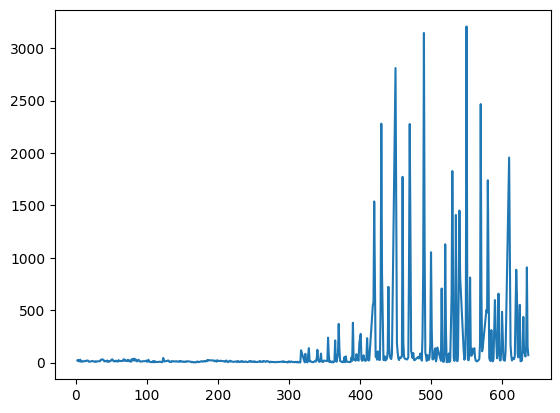

In [22]:
plt.plot(df_outliers_count['frequency'], df_outliers_count['XX'])

In [23]:
df_outliers_location = pd.DataFrame()
for ii in range(4):
    for i in range(len(parts)):
        for k in range(1): #len(polarizations)):
            for l in range(len(integ)):
                for o in range(len(gn)):
                    print(outlier_path+"outliers_location_day_%s_grid_%s_integration_%s_%s_part_%s_gp_%s.h5" %(ii+1, gn[o], integ[l][0], parts[i], ii+1, gn[o]))
                    
                    aa = load_outliers_location_h5(outlier_path+"outliers_location_day_%s_grid_%s_integration_%s_%s_part_%s_gp_%s.h5" %(ii+1, gn[o], integ[l][0], parts[i], ii+1, gn[o]), polarizations)
                    df_outliers_location = pd.concat([df_outliers_location, aa]).reset_index(drop = True)

/Volumes/eor_hdd_2/results_observation_260317/outliers_location_day_1_grid_0_integration_2_phase_part_1_gp_0.h5
Outliers:  (896, 128, 640, 4)
/Volumes/eor_hdd_2/results_observation_260317/outliers_location_day_1_grid_1_integration_2_phase_part_1_gp_1.h5
Outliers:  (448, 128, 640, 4)
/Volumes/eor_hdd_2/results_observation_260317/outliers_location_day_1_grid_2_integration_2_phase_part_1_gp_2.h5
Outliers:  (504, 128, 640, 4)
/Volumes/eor_hdd_2/results_observation_260317/outliers_location_day_2_grid_0_integration_2_phase_part_2_gp_0.h5
Outliers:  (784, 128, 640, 4)
/Volumes/eor_hdd_2/results_observation_260317/outliers_location_day_2_grid_1_integration_2_phase_part_2_gp_1.h5
Outliers:  (280, 128, 640, 4)
/Volumes/eor_hdd_2/results_observation_260317/outliers_location_day_2_grid_2_integration_2_phase_part_2_gp_2.h5
Outliers:  (336, 128, 640, 4)
/Volumes/eor_hdd_2/results_observation_260317/outliers_location_day_3_grid_0_integration_2_phase_part_3_gp_0.h5
Outliers:  (896, 128, 640, 4)
/Volum

In [24]:
df_outliers_location[df_outliers_location['XX'] & df_outliers_location['YY']].reset_index()

,index,XX,XY,YX,YY,obs_id,time_index,frequency,antenna,timeblock
0,390852,True,False,False,True,1095450704,4,452,98,4
1,390909,True,False,False,True,1095450704,4,509,98,4
2,413380,True,False,False,True,1095450704,5,580,5,5
3,415940,True,False,False,True,1095450704,5,580,9,5
4,430660,True,False,False,True,1095450704,5,580,32,5
...,...,...,...,...,...,...,...,...,...,...
72504,531690140,True,False,False,True,1098296680,330,540,45,50
72505,531695260,True,False,False,True,1098296680,330,540,53,50
72506,531731800,True,False,False,True,1098296680,330,600,110,50
72507,531732440,True,False,False,True,1098296680,330,600,111,50


In [ ]:
for ii in range(len(parts)):
    for jj in range(len(threshold_type)):
        for kk in range(len(integ)):

            fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 6))
            fig.suptitle('Statistical properties plot_type: %s, integration_time: %s, and threshold_type: %s' %(parts[ii], integ[kk], threshold_type[jj]), size=14, y=0.97)

            for ll in range(len(sn)):

                sel_df = df_stats[(df_stats['integration'] == integ[kk]) & (df_stats['plot_type'] == parts[ii]) & (df_stats['sn'] == sn[ll]) & (df_stats['threshold_type'] == threshold_type[jj])][['z_score', 'tp', 'fp', 'f1', 'tp_rate', 'fp_rate']].reset_index(drop=True)

                z_alias['tp'] = z_alias.z_score.map(sel_df.set_index('z_score')['tp_rate'])
                z_alias['fp'] = z_alias.z_score.map(sel_df.set_index('z_score')['fp_rate'])
                z_alias['f1'] = z_alias.z_score.map(sel_df.set_index('z_score')['f1'])

                axes[0].plot(z_score, (z_alias['tp']), label=str(sn[ll]))
                axes[0].set_title('True positive rate', color='k', size=12)
                axes[0].axvline(x=3, color='red', linestyle='--')
                axes[0].axvline(x=5, color='blue', linestyle='--')
                axes[0].axvline(x=10, color='black', linestyle='--')

                axes[1].plot(z_score, (z_alias['fp']), label=str(sn[ll]))
                axes[1].set_title('False positive rate', color='k', size=12)
                axes[1].axvline(x=3, color='red', linestyle='--')
                axes[1].axvline(x=5, color='blue', linestyle='--')
                axes[1].axvline(x=10, color='black', linestyle='--')

                axes[2].plot(z_score, (z_alias['f1']), label=str(sn[ll]))
                axes[2].set_title('F1 score', color='k', size=12)
                axes[2].axvline(x=3, color='red', linestyle='--')
                axes[2].axvline(x=5, color='blue', linestyle='--')
                axes[2].axvline(x=10, color='black', linestyle='--')
            
            fig.text(0.35, 0.04, "Z score", size=14, ha='center')
            plt.legend(loc='lower right')
            plt.savefig("/Users/eormacstudio/Documents/GitHub/GRANDWin/test/results/plot_confusion/statistical_properties_plot_type_%s_integration_time_%s_threshold_type_%s.png" %(parts[ii], integ[kk], threshold_type[jj]), dpi=140)